# Experimento de Fechamento — ASJM (Adaptive Statistical Jump Model)

**Pergunta de pesquisa.** O ASJM acionado pela estabilidade do *cluster* de regimes
(via ΔARI sequencial e MRL) supera a melhor configuração calendária identificada
pela varredura W1 (Notebook 13)?

**Hipótese única (H_fecho).** Sob o universo de 3 ativos da W1
(LargeCap, MidCap, SmallCap) e janela 2007–2023, o ASJM supera o vencedor da W1
em pelo menos uma das três frentes: riqueza terminal fora da amostra, atraso
médio de detecção, ou estabilidade de ordenamento entre validação e fora da
amostra.

## Princípios de validade da comparação

Para que a comparação seja interpretável, o experimento adota as **mesmas
condições da W1** em tudo, exceto na regra de recalibração:

* mesmo universo: LargeCap, MidCap, SmallCap
* mesma janela: 2007-01-01 a 2023-12-31
* mesma partição walk-forward: 60% validação / 40% holdout
* mesma quantidade de sementes: 5
* mesma configuração base (vencedor da W1): λ = 25, YZ, k = 2, previsor logístico

A única dimensão alterada é a frequência de recalibração:
* **W1-vencedor** (linha de base 1): recalibração anual fixa
* **Shu et al. 2024** (linha de base 2): semestral fixa, λ = 50, CC, XGBoost
* **ASJM** (tratamento): recalibração acionada por ΔARI < θ_ARI ou MRL < θ_MRL

## Calibração dos limiares do gatilho

Os limiares θ_ARI e θ_MRL são calibrados em janela disjunta (2002 a 2006) usando
o quinto percentil das distribuições empíricas. **Não há reotimização** após a
calibração inicial — esta é uma versão estática do ASJM, sem o mecanismo de
e-processo descrito na Seção 7.2.1 da dissertação.

## 1 · Imports e configuração

In [1]:
import sys
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dataclasses import dataclass, field, asdict
from typing import List, Tuple, Dict, Optional, Any

from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.config.settings import (
    ASSETS, ASSET_TICKERS, FRED_SERIES, DATA_START, DATA_END,
    TEST_START, TEST_END, TRAIN_YEARS, TRADING_DAYS_YEAR,
    LEVERAGE_MAX, WEIGHT_UB, TRANSACTION_COST,
)
from src.ablation.ablation_runner import (
    AblationConfig, AblationResult,
    prepare_ablation_data,
    _rebal_months_from_freq,
    _generate_refit_dates,
    _prepare_clustering_features,
    _forecast_regime,
    _simple_portfolio,
    _align_true_regimes,
    W1_VALIDATION_FRACTION,
)
from src.ablation.regime_diagnostics import (
    compute_ari, mean_run_length, regime_diagnostics_summary,
)
from src.ablation.jit_metrics import compute_metrics_array
from src.ablation.polars_utils import float_nan_to_null
from src.models.jump_model import JumpModel
from sklearn.metrics import f1_score
import time

# Universo idêntico ao W1
ASSETS_RUN: List[str] = ['LargeCap', 'MidCap', 'SmallCap']
N_SEEDS: int = 5
SEEDS: List[int] = list(range(N_SEEDS))

# Janelas: calibração 2002-2006 (anterior ao TEST_START) e teste 2007-2023
CALIBRATION_START = '2002-01-01'
CALIBRATION_END   = '2006-12-31'

# Diretórios
RESULTS_DIR = ROOT / 'results' / 'ablation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = RESULTS_DIR / 'asjm_proof_of_concept.parquet'

print(f'Universo: {ASSETS_RUN}')
print(f'Sementes: {SEEDS}')
print(f'Janela de calibração: {CALIBRATION_START} → {CALIBRATION_END}')
print(f'Janela de teste:      {TEST_START} → {TEST_END}')
print(f'Saída:                {OUT_PATH}')


Universo: ['LargeCap', 'MidCap', 'SmallCap']
Sementes: [0, 1, 2, 3, 4]
Janela de calibração: 2002-01-01 → 2006-12-31
Janela de teste:      2007-01-01 → 2023-12-31
Saída:                /home/researcher/app/results/ablation/asjm_proof_of_concept.parquet


## 2 · Carga de dados

Reaproveita o mesmo carregamento da W1: preços ajustados, retornos, FRED e estimadores
de volatilidade. As features são pré-computadas para os 3 ativos.

In [2]:
loader = DataLoader(cache_dir=str(ROOT / 'data' / 'raw'))
prices   = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
fred_raw = loader.load_fred(FRED_SERIES, start=DATA_START, end=DATA_END)

preprocessor = DataPreprocessor()
er, rf, fred = preprocessor.prepare(prices, fred_raw)

print(f'Retornos (excess): {er.shape[0]} dias, {er.shape[1]} ativos.')
print(f'Período:           {er.index[0].date()} → {er.index[-1].date()}')

# Prepara dados para os 3 ativos (OHLC, features, vol estimators, regimes de consenso)
asset_data = {}
for asset in ASSETS_RUN:
    print(f'  preparando {asset}...', flush=True)
    asset_data[asset] = prepare_ablation_data(
        asset=asset, er=er, rf=rf, fred=fred,
    )

print('Dados preparados para os 3 ativos.')


Retornos (excess): 5940 dias, 12 ativos.
Período:           2000-05-22 → 2023-12-29
  preparando LargeCap...
  preparando MidCap...
  preparando SmallCap...
Dados preparados para os 3 ativos.


## 3 · Configurações comparadas

Três configurações são avaliadas no mesmo motor de simulação. Apenas a regra
de recalibração difere.

In [3]:
# Linha de base 1 — vencedor da W1 (calendário anual)
CFG_W1_WINNER = AblationConfig(
    name='w1_winner_annual',
    description='Vencedor da W1: lambda=25, YZ, k=2, anual, logistic',
    ablation_id='ASJM-POC',
    lambda_penalty=25.0,
    n_regimes=2,
    vol_estimator='yz',
    forecaster_type='logistic_regression',
    recal_frequency='annual',
)

# Linha de base 2 — Shu et al. (2024) replicado
CFG_SHU = AblationConfig(
    name='shu2024_semiannual',
    description='Replicação Shu et al. 2024: lambda=50, CC, k=2, semestral, XGBoost',
    ablation_id='ASJM-POC',
    lambda_penalty=50.0,
    n_regimes=2,
    vol_estimator='close_to_close',
    forecaster_type='xgboost',
    recal_frequency='semi-annual',
)

# Tratamento — ASJM (mesma config base do W1-vencedor; recal acionada por ARI/MRL)
CFG_ASJM = AblationConfig(
    name='asjm_cluster_stability',
    description='ASJM: lambda=25, YZ, k=2, gatilho ARI+MRL, logistic',
    ablation_id='ASJM-POC',
    lambda_penalty=25.0,
    n_regimes=2,
    vol_estimator='yz',
    forecaster_type='logistic_regression',
    recal_frequency='asjm',  # rótulo; rebalanceamento controlado por gatilho
)

# Constantes do gatilho
T_MAX_MONTHS_ASJM = 24       # gatilho calendário de segurança (24 meses)
ARI_PERCENTILE    = 5         # quinto percentil empírico
MRL_PERCENTILE    = 5
EVAL_FREQ         = 'quarterly'  # checa o gatilho a cada 3 meses


## 4 · Calibração dos limiares θ_ARI e θ_MRL

Os limiares são derivados de uma janela disjunta da janela de teste, 2002–2006.
Para cada ativo:

1. Ajusta o JM em janelas de 252 dias úteis (rolagem trimestral).
2. Calcula ΔARI(τ) entre cada par de ajustes consecutivos no overlap.
3. Calcula MRL(τ) sobre cada janela de 252 dias.
4. Toma o quinto percentil empírico das duas distribuições.

Os limiares são calibrados **por ativo**, refletindo o Direcionamento 5 da
dissertação (Seção 7.5).

In [4]:
def calibrate_thresholds_for_asset(
    asset: str,
    er_df: pd.DataFrame,
    features: pd.DataFrame,
    vol_estimators: Dict[str, np.ndarray],
    cfg: AblationConfig,
    seed: int = 0,
    cal_start: str = CALIBRATION_START,
    cal_end:   str = CALIBRATION_END,
) -> Dict[str, float]:
    """Calibra theta_ARI e theta_MRL para um ativo na janela de calibração."""
    np.random.seed(seed)
    idx = er_df.index
    cal_idx = idx[(idx >= cal_start) & (idx <= cal_end)]
    if len(cal_idx) < 504:  # mínimo 2 anos
        return {'theta_ari': 0.5, 'theta_mrl': 30.0}

    # Volatilidade YZ (config base)
    vol_key = cfg.vol_estimator
    vol_series = vol_estimators.get(vol_key, vol_estimators['close_to_close'])
    vol_s = pd.Series(vol_series, index=idx).reindex(idx).ffill()
    feat_enriched = _prepare_clustering_features(features, vol_s, cfg.feature_set)

    # Janelas trimestrais de 252 dias úteis
    eval_dates = []
    seen = set()
    for dt in cal_idx:
        if dt.month in (1, 4, 7, 10) and (dt.year, dt.month) not in seen:
            eval_dates.append(dt)
            seen.add((dt.year, dt.month))

    aris  = []
    mrls  = []
    prev_labels = None
    prev_dates  = None

    for dt in eval_dates:
        train_idx = idx[(idx <= dt) & (idx >= dt - pd.Timedelta(days=370))]
        X_train = feat_enriched.reindex(train_idx).dropna()
        if len(X_train) < 100:
            continue
        try:
            jm = JumpModel(n_states=cfg.n_regimes, jump_pen=cfg.lambda_penalty, random_state=seed)
            jm.fit(X_train.values)
            labels = jm.labels_
        except Exception:
            continue

        # MRL desta janela
        mrl_dict = mean_run_length(labels)
        mrl_now = float(mrl_dict.get('mean_all', np.nan)) if isinstance(mrl_dict, dict) else float('nan')
        if np.isfinite(mrl_now):
            mrls.append(mrl_now)

        # ARI contra a janela anterior, no overlap
        if prev_labels is not None and prev_dates is not None:
            common = X_train.index.intersection(prev_dates)
            if len(common) > 30:
                a_now  = pd.Series(labels, index=X_train.index).reindex(common).values
                a_prev = pd.Series(prev_labels, index=prev_dates).reindex(common).values
                ari_v = compute_ari(a_prev, a_now)
                if np.isfinite(ari_v):
                    aris.append(ari_v)

        prev_labels = labels
        prev_dates  = X_train.index

    if not aris or not mrls:
        return {'theta_ari': 0.5, 'theta_mrl': 30.0}

    theta_ari = float(np.percentile(aris, ARI_PERCENTILE))
    theta_mrl = float(np.percentile(mrls, MRL_PERCENTILE))
    return {
        'theta_ari': theta_ari,
        'theta_mrl': theta_mrl,
        'n_ari_obs': len(aris),
        'n_mrl_obs': len(mrls),
        'mean_ari':  float(np.mean(aris)),
        'mean_mrl':  float(np.mean(mrls)),
    }

# Calibra por ativo (média sobre 3 sementes da janela de calibração)
THRESHOLDS = {}
for asset in ASSETS_RUN:
    ohlc, features, vol_est, _true_reg = asset_data[asset]
    samples = []
    for s in [0, 1, 2]:
        thr = calibrate_thresholds_for_asset(
            asset=asset, er_df=er, features=features,
            vol_estimators=vol_est, cfg=CFG_ASJM, seed=s,
        )
        samples.append(thr)
    THRESHOLDS[asset] = {
        'theta_ari': float(np.mean([s['theta_ari'] for s in samples])),
        'theta_mrl': float(np.mean([s['theta_mrl'] for s in samples])),
    }

print('Limiares calibrados (média sobre 3 sementes da janela 2002-2006):')
print(pd.DataFrame(THRESHOLDS).T.round(4).to_string())


Limiares calibrados (média sobre 3 sementes da janela 2002-2006):
          theta_ari  theta_mrl
LargeCap    -0.0813    47.5889
MidCap      -0.0053    99.3333
SmallCap    -0.0033    92.1389


## 5 · Implementação do gatilho ASJM

A função `generate_asjm_refit_dates` substitui `_generate_refit_dates` (calendário fixo)
por uma regra acionada por evento:

1. A cada data de **avaliação** (trimestralmente, no início do trimestre), ajusta o JM
   em janela de 252 dias e calcula ΔARI contra a última recalibração e MRL atual.
2. Se ΔARI < θ_ARI **ou** MRL < θ_MRL **ou** já passou T_max meses desde a última
   recalibração → recalibra (gera novo bloco).
3. Caso contrário, mantém o bloco anterior estendido até a próxima avaliação.

Cada bloco gerado tem o mesmo formato dos blocos calendários: `(train_end, test_start, test_end)`.

In [5]:
def generate_asjm_refit_dates(
    asset: str,
    er_df: pd.DataFrame,
    features: pd.DataFrame,
    vol_estimators: Dict[str, np.ndarray],
    cfg: AblationConfig,
    seed: int,
    test_start: str = TEST_START,
    test_end:   str = TEST_END,
    t_max_months: int = T_MAX_MONTHS_ASJM,
    eval_freq:    str = EVAL_FREQ,
) -> Tuple[List[Tuple[pd.Timestamp, pd.Timestamp, pd.Timestamp]],
           List[Dict[str, Any]]]:
    """
    Gera blocos de recalibração acionados pelo gatilho ARI+MRL.

    Returns
    -------
    blocks : lista de (train_end, test_start, test_end)
    events : lista de dicionários com data, motivo e estatísticas do gatilho
    """
    np.random.seed(seed)
    idx = er_df.index
    test_idx = idx[(idx >= test_start) & (idx <= test_end)]
    if len(test_idx) == 0:
        return [], []

    theta_ari = THRESHOLDS[asset]['theta_ari']
    theta_mrl = THRESHOLDS[asset]['theta_mrl']

    # Datas de avaliação: trimestrais
    eval_months = _rebal_months_from_freq(eval_freq)
    eval_dates: List[pd.Timestamp] = []
    seen = set()
    for dt in test_idx:
        if dt.month in eval_months and (dt.year, dt.month) not in seen:
            eval_dates.append(dt)
            seen.add((dt.year, dt.month))

    # Volatilidade
    vol_key = cfg.vol_estimator
    vol_series = vol_estimators.get(vol_key, vol_estimators['close_to_close'])
    vol_s = pd.Series(vol_series, index=idx).reindex(idx).ffill()
    feat_enriched = _prepare_clustering_features(features, vol_s, cfg.feature_set)

    blocks: List[Tuple[pd.Timestamp, pd.Timestamp, pd.Timestamp]] = []
    events: List[Dict[str, Any]] = []
    last_refit_dt: Optional[pd.Timestamp] = None
    last_labels = None
    last_train_idx = None

    for i, dt in enumerate(eval_dates):
        # Define janela de treino expandindo até dt-1
        train_idx_full = idx[idx <= dt - pd.Timedelta(days=1)]
        # Limita a janela de treino aos TRAIN_YEARS anos
        train_start = dt - pd.Timedelta(days=int(cfg.train_years * 365.25))
        train_idx = train_idx_full[train_idx_full >= train_start]
        X_train = feat_enriched.reindex(train_idx).dropna()
        if len(X_train) < 252:
            continue

        # Ajusta o JM nesta janela
        try:
            jm = JumpModel(
                n_states=cfg.n_regimes,
                jump_pen=cfg.lambda_penalty,
                random_state=seed,
            )
            jm.fit(X_train.values)
            cur_labels = jm.labels_
        except Exception:
            continue

        # Calcula MRL na janela atual
        mrl_dict = mean_run_length(cur_labels)
        mrl_now = float(mrl_dict.get('mean_all', np.nan)) if isinstance(mrl_dict, dict) else float('nan')
        # Calcula ARI contra o último ajuste (no overlap)
        ari_now = np.nan
        if last_labels is not None and last_train_idx is not None:
            common = X_train.index.intersection(last_train_idx)
            if len(common) > 30:
                a_now = pd.Series(cur_labels, index=X_train.index).reindex(common).values
                a_prev = pd.Series(last_labels, index=last_train_idx).reindex(common).values
                ari_now = compute_ari(a_prev, a_now)

        # Decide se aciona recalibração
        reason = None
        time_since_last = None
        if last_refit_dt is not None:
            time_since_last = (dt - last_refit_dt).days

        # Critério 1: primeira recalibração (sempre)
        if last_refit_dt is None:
            reason = 'initial'
        # Critério 2: ΔARI baixo (queda de concordância)
        elif np.isfinite(ari_now) and ari_now < theta_ari:
            reason = 'ari_collapse'
        # Critério 3: MRL baixo (oscilação rápida)
        elif np.isfinite(mrl_now) and mrl_now < theta_mrl:
            reason = 'mrl_collapse'
        # Critério 4: gatilho calendário de segurança
        elif time_since_last is not None and time_since_last >= t_max_months * 30:
            reason = 'calendar_safety'

        if reason is not None:
            train_end = dt - pd.Timedelta(days=1)
            tstart = dt
            tend = eval_dates[i + 1] - pd.Timedelta(days=1) if i + 1 < len(eval_dates) else pd.Timestamp(test_end)
            blocks.append((train_end, tstart, tend))
            events.append({
                'asset': asset,
                'seed': seed,
                'date': dt,
                'reason': reason,
                'ari_now': float(ari_now) if np.isfinite(ari_now) else None,
                'mrl_now': float(mrl_now) if np.isfinite(mrl_now) else None,
                'theta_ari': theta_ari,
                'theta_mrl': theta_mrl,
                'days_since_last': time_since_last,
            })
            last_refit_dt = dt
            last_labels = cur_labels
            last_train_idx = X_train.index
        else:
            # Estende o bloco anterior
            if blocks:
                train_end, tstart, _old_end = blocks[-1]
                new_end = eval_dates[i + 1] - pd.Timedelta(days=1) if i + 1 < len(eval_dates) else pd.Timestamp(test_end)
                blocks[-1] = (train_end, tstart, new_end)

    return blocks, events


## 6 · Pipeline com blocos personalizados

Adapta o motor de simulação para aceitar blocos pré-computados, em vez de gerar
blocos calendários internamente. Mantém todos os outros componentes da W1 (Stage 1
JM, Stage 2 forecaster, Stage 3 portfolio binário 0/1).

In [6]:
def run_with_custom_blocks(
    config: AblationConfig,
    asset:  str,
    er_df:  pd.DataFrame,
    rf_s:   pd.Series,
    features: pd.DataFrame,
    vol_estimators: Dict[str, np.ndarray],
    true_regimes:  np.ndarray,
    blocks: List[Tuple[pd.Timestamp, pd.Timestamp, pd.Timestamp]],
    seed:   int = 0,
) -> AblationResult:
    """Versão de run_single_ablation com blocos passados externamente."""
    np.random.seed(seed)
    result = AblationResult(
        ablation_id=config.ablation_id,
        asset=asset,
        config=config.name,
        seed=seed,
    )
    if not blocks:
        return result

    idx = er_df.index
    vol_key = config.vol_estimator
    vol_series = vol_estimators.get(vol_key, vol_estimators['close_to_close'])
    vol_s = pd.Series(vol_series, index=idx).reindex(idx).ffill()
    feat_enriched = _prepare_clustering_features(features, vol_s, config.feature_set)

    all_preds: List[np.ndarray] = []
    all_true:  List[np.ndarray] = []
    all_returns: List[np.ndarray] = []

    for train_end, test_start_bl, test_end_bl in blocks:
        train_idx = idx[idx <= train_end]
        test_idx  = idx[(idx >= test_start_bl) & (idx <= test_end_bl)]
        if len(train_idx) < 252 or len(test_idx) == 0:
            continue
        X_train = feat_enriched.reindex(train_idx).dropna()
        if len(X_train) < 100:
            continue
        try:
            jm = JumpModel(n_states=config.n_regimes, jump_pen=config.lambda_penalty, random_state=seed)
            jm.fit(X_train.values)
        except Exception:
            continue

        er_train = er_df[asset].reindex(X_train.index).values
        stats_dict = jm.regime_stats(er_train)
        bull_state = max(stats_dict, key=lambda k: stats_dict[k]['mean_daily'])
        jm_labels = (jm.labels_ != bull_state).astype(int)

        X_test = feat_enriched.reindex(test_idx).ffill().dropna()
        if len(X_test) == 0:
            continue
        predicted = _forecast_regime(
            config=config, X_train=X_train, y_train=jm_labels,
            X_test=X_test, seed=seed,
        )
        er_test = er_df[asset].reindex(test_idx).fillna(0.0).values
        port_ret = _simple_portfolio(
            pred_labels=predicted, er=er_test,
            gamma_trade=config.gamma_trade, gamma_risk=config.gamma_risk,
            leverage_max=config.leverage_max,
        )
        true_block = _align_true_regimes(true_regimes, features.index, test_idx)
        all_preds.append(predicted)
        all_true.append(true_block)
        all_returns.append(port_ret)

    if not all_preds:
        return result

    preds_all = np.concatenate(all_preds)
    true_all  = np.concatenate(all_true)
    rets_all  = np.concatenate(all_returns)
    rf_d = float(rf_s.mean())

    diag = regime_diagnostics_summary(true_all, preds_all)
    result.add = diag['ADD']
    result.miss_rate = diag['MissRate']
    result.false_alarm_rate = diag['FAR']
    result.regime_ari = diag['ARI']
    result.mean_run_length = diag['MRL_all']
    result.cp_accuracy = diag['CP_Accuracy']
    result.cp_balanced_accuracy = diag['CP_BalancedAccuracy']
    result.state_accuracy = diag['StateAccuracy']
    result.accuracy = diag['StateAccuracy']
    result.state_balanced_accuracy = diag['StateBalancedAccuracy']
    result.f1_score = float(f1_score(true_all, preds_all, average='binary', zero_division=0))

    pm = compute_metrics_array(rets_all, rf_daily=rf_d, ann_factor=TRADING_DAYS_YEAR)
    result.sortino_ratio = pm['Sortino']
    result.sharpe_ratio  = pm['Sharpe']
    result.max_drawdown  = pm['MDD']
    result.calmar_ratio  = pm['Calmar']
    result.total_return  = float(np.sum(rets_all) * TRADING_DAYS_YEAR / len(rets_all))
    result.volatility    = float(np.std(rets_all, ddof=1) * np.sqrt(TRADING_DAYS_YEAR))
    result.terminal_wealth = float(np.prod(1.0 + rets_all))
    if len(rets_all) >= 2:
        split = max(1, int(round(len(rets_all) * W1_VALIDATION_FRACTION)))
        split = min(split, len(rets_all) - 1)
        result.terminal_wealth_val = float(np.prod(1.0 + rets_all[:split]))
        result.terminal_wealth_oos = float(np.prod(1.0 + rets_all[split:]))

    pos_changes = np.abs(np.diff(np.concatenate([[0], preds_all])))
    result.turnover = float(pos_changes.mean() * TRADING_DAYS_YEAR)
    result.n_position_switches = float(pos_changes.sum())

    return result


## 7 · Execução das três configurações

In [7]:
def run_one(asset: str, cfg: AblationConfig, seed: int):
    ohlc, features, vol_est, true_reg = asset_data[asset]
    if cfg.recal_frequency == 'asjm':
        blocks, events = generate_asjm_refit_dates(
            asset=asset, er_df=er, features=features,
            vol_estimators=vol_est, cfg=cfg, seed=seed,
        )
    else:
        rebal_months = _rebal_months_from_freq(cfg.recal_frequency)
        blocks = _generate_refit_dates(er.index, TEST_START, TEST_END, rebal_months, cfg.train_years)
        events = []
    res = run_with_custom_blocks(
        config=cfg, asset=asset, er_df=er, rf_s=rf,
        features=features, vol_estimators=vol_est, true_regimes=true_reg,
        blocks=blocks, seed=seed,
    )
    res_dict = asdict(res)
    res_dict['n_blocks'] = len(blocks)
    res_dict['events']   = events
    return res_dict

results_rows: List[Dict[str, Any]] = []
all_events:  List[Dict[str, Any]] = []
configs = [CFG_W1_WINNER, CFG_SHU, CFG_ASJM]

t0 = time.time()
for cfg in configs:
    for asset in ASSETS_RUN:
        for seed in SEEDS:
            res_dict = run_one(asset, cfg, seed)
            evs = res_dict.pop('events', [])
            all_events.extend(evs)
            results_rows.append(res_dict)
            print(f'  [{cfg.name:30s}] {asset:9s} seed={seed} '
                  f'W_full={res_dict.get("terminal_wealth", float("nan")):.3f} '
                  f'W_oos={res_dict.get("terminal_wealth_oos", float("nan")):.3f} '
                  f'n_blocks={res_dict["n_blocks"]}')
elapsed_min = (time.time() - t0) / 60
print(f'Tempo total: {elapsed_min:.1f} min.')

results_df = pd.DataFrame(results_rows)
events_df  = pd.DataFrame(all_events)
print(f'Linhas: {len(results_df)}; eventos de gatilho ASJM: {len(events_df)}')


  [w1_winner_annual              ] LargeCap  seed=0 W_full=43.630 W_oos=5.027 n_blocks=17
  [w1_winner_annual              ] LargeCap  seed=1 W_full=39.394 W_oos=4.371 n_blocks=17
  [w1_winner_annual              ] LargeCap  seed=2 W_full=40.149 W_oos=4.453 n_blocks=17
  [w1_winner_annual              ] LargeCap  seed=3 W_full=43.450 W_oos=5.267 n_blocks=17
  [w1_winner_annual              ] LargeCap  seed=4 W_full=40.385 W_oos=4.976 n_blocks=17
  [w1_winner_annual              ] MidCap    seed=0 W_full=19.135 W_oos=4.744 n_blocks=17
  [w1_winner_annual              ] MidCap    seed=1 W_full=14.462 W_oos=2.934 n_blocks=17
  [w1_winner_annual              ] MidCap    seed=2 W_full=20.003 W_oos=3.296 n_blocks=17
  [w1_winner_annual              ] MidCap    seed=3 W_full=20.025 W_oos=2.458 n_blocks=17
  [w1_winner_annual              ] MidCap    seed=4 W_full=12.186 W_oos=1.352 n_blocks=17
  [w1_winner_annual              ] SmallCap  seed=0 W_full=25.967 W_oos=3.966 n_blocks=17
  [w1_winn

## 8 · Resumo agregado por configuração

In [8]:
metric_cols = [
    'terminal_wealth', 'terminal_wealth_val', 'terminal_wealth_oos',
    'sharpe_ratio', 'sortino_ratio', 'max_drawdown', 'calmar_ratio',
    'volatility', 'turnover', 'n_position_switches',
    'add', 'miss_rate', 'false_alarm_rate', 'regime_ari', 'mean_run_length',
    'n_blocks',
]
summary = (results_df.groupby('config')[metric_cols]
                     .agg(['mean','std'])
                     .round(4))
print('=== Resumo agregado por configuração (média ± desvio sobre 3 ativos × 5 sementes) ===')
print(summary.to_string())


=== Resumo agregado por configuração (média ± desvio sobre 3 ativos × 5 sementes) ===
                       terminal_wealth          terminal_wealth_val         terminal_wealth_oos         sharpe_ratio         sortino_ratio         max_drawdown         calmar_ratio         volatility         turnover         n_position_switches               add          miss_rate         false_alarm_rate         regime_ari         mean_run_length          n_blocks        
                                  mean      std                mean     std                mean     std         mean     std          mean     std         mean     std         mean     std       mean     std     mean     std                mean      std     mean      std      mean     std             mean     std       mean     std            mean      std     mean     std
config                                                                                                                                                            

## 9 · Comparação direta — ASJM contra os dois baselines

In [9]:
asjm_mean = results_df.query('config == "asjm_cluster_stability"')[metric_cols].mean()
w1_mean   = results_df.query('config == "w1_winner_annual"')[metric_cols].mean()
shu_mean  = results_df.query('config == "shu2024_semiannual"')[metric_cols].mean()

cmp = pd.concat({
    'Shu (semestral)':    shu_mean,
    'W1-vencedor (anual)': w1_mean,
    'ASJM (gatilho)':      asjm_mean,
}, axis=1).round(4)
cmp['Δ ASJM-Shu']  = (asjm_mean - shu_mean).round(4)
cmp['Δ ASJM-W1']   = (asjm_mean - w1_mean).round(4)

print('=== Comparação direta ===')
print(cmp.to_string())


=== Comparação direta ===
                     Shu (semestral)  W1-vencedor (anual)  ASJM (gatilho)  Δ ASJM-Shu  Δ ASJM-W1
terminal_wealth               7.8096              26.4984         26.7897     18.9802     0.2913
terminal_wealth_val           3.0836               7.7293          7.1275      4.0439    -0.6018
terminal_wealth_oos           2.3326               3.4901          3.6604      1.3279     0.1703
sharpe_ratio                  0.7809               1.4021          1.4094      0.6285     0.0072
sortino_ratio                 1.1596               2.2273          2.2313      1.0718     0.0040
max_drawdown                 -0.3264              -0.1554         -0.1635      0.1629    -0.0081
calmar_ratio                  0.6418               1.4762          1.9470      1.3053     0.4709
volatility                    0.1585               0.1435          0.1452     -0.0133     0.0017
turnover                      5.5175               8.6474          9.1383      3.6208     0.4909
n_po

## 10 · Teste estatístico — Wilcoxon pareado por ativo

Compara o ASJM contra cada baseline pareando por (ativo, semente).

In [10]:
from scipy.stats import wilcoxon

def paired_wilcoxon(metric: str, treatment_cfg: str, baseline_cfg: str):
    a = results_df.query(f'config == "{treatment_cfg}"').sort_values(['asset','seed'])[metric].values
    b = results_df.query(f'config == "{baseline_cfg}"').sort_values(['asset','seed'])[metric].values
    if len(a) != len(b) or len(a) < 6:
        return {'metric': metric, 'n': len(a), 'mean_diff': np.nan, 'p_value': np.nan}
    diffs = a - b
    if np.allclose(diffs, 0):
        return {'metric': metric, 'n': len(a), 'mean_diff': 0.0, 'p_value': 1.0}
    stat, p = wilcoxon(diffs, zero_method='zsplit')
    return {'metric': metric, 'n': len(a),
            'mean_diff': float(np.mean(diffs)), 'median_diff': float(np.median(diffs)),
            'wilcoxon_stat': float(stat), 'p_value': float(p)}

tests_vs_w1  = []
tests_vs_shu = []
for m in ['terminal_wealth_oos', 'terminal_wealth', 'sharpe_ratio',
         'sortino_ratio', 'max_drawdown', 'turnover', 'add']:
    tests_vs_w1.append(paired_wilcoxon(m, 'asjm_cluster_stability', 'w1_winner_annual'))
    tests_vs_shu.append(paired_wilcoxon(m, 'asjm_cluster_stability', 'shu2024_semiannual'))

print('=== ASJM vs W1-vencedor (Wilcoxon pareado, n = 15) ===')
print(pd.DataFrame(tests_vs_w1).round(4).to_string(index=False))
print('\n=== ASJM vs Shu et al. 2024 (Wilcoxon pareado, n = 15) ===')
print(pd.DataFrame(tests_vs_shu).round(4).to_string(index=False))


=== ASJM vs W1-vencedor (Wilcoxon pareado, n = 15) ===
             metric  n  mean_diff  median_diff  wilcoxon_stat  p_value
terminal_wealth_oos 15     0.1703       0.4247           37.0   0.2078
    terminal_wealth 15     0.2913      -0.4114           58.0   0.9341
       sharpe_ratio 15     0.0072       0.0534           59.0   0.9780
      sortino_ratio 15     0.0040       0.1109           59.0   0.9780
       max_drawdown 15    -0.0081       0.0195           56.0   0.8202
           turnover 15     0.4909       0.3534           39.0   0.2325
                add 15    -1.9954       0.0333           49.0   0.5320

=== ASJM vs Shu et al. 2024 (Wilcoxon pareado, n = 15) ===
             metric  n  mean_diff  median_diff  wilcoxon_stat  p_value
terminal_wealth_oos 15     1.3279       1.2340            0.0   0.0001
    terminal_wealth 15    18.9802      20.6737            0.0   0.0001
       sharpe_ratio 15     0.6285       0.6171            0.0   0.0001
      sortino_ratio 15     1.0718

## 11 · Análise dos eventos de gatilho do ASJM

In [11]:
if not events_df.empty:
    print('=== Distribuição de eventos por motivo ===')
    print(events_df.groupby('reason').size().to_frame('n_events').to_string())
    print('\n=== Eventos por ativo (médias sobre sementes) ===')
    per_asset = events_df.groupby(['asset','reason']).size().unstack(fill_value=0)
    print(per_asset.to_string())
    print('\n=== Estatísticas dos eventos ARI/MRL ===')
    ari_evs = events_df.query('reason == "ari_collapse"')
    mrl_evs = events_df.query('reason == "mrl_collapse"')
    if len(ari_evs):
        print(f'ARI collapse: n={len(ari_evs)}, ari_now mean={ari_evs["ari_now"].mean():.3f}')
    if len(mrl_evs):
        print(f'MRL collapse: n={len(mrl_evs)}, mrl_now mean={mrl_evs["mrl_now"].mean():.1f}')
else:
    print('Nenhum evento ASJM registrado.')


=== Distribuição de eventos por motivo ===
                 n_events
reason                   
ari_collapse          126
calendar_safety        73
initial                15

=== Eventos por ativo (médias sobre sementes) ===
reason    ari_collapse  calendar_safety  initial
asset                                           
LargeCap             0               40        5
MidCap              55               17        5
SmallCap            71               16        5

=== Estatísticas dos eventos ARI/MRL ===
ARI collapse: n=126, ari_now mean=-0.039


## 12 · Verificação da hipótese de fechamento

In [12]:
dW_oos = asjm_mean['terminal_wealth_oos'] - w1_mean['terminal_wealth_oos']
dADD   = asjm_mean['add']                 - w1_mean['add']  # menor é melhor

print('=== H_fecho: ASJM > vencedor-W1 em ao menos uma frente? ===')
print(f'  Δ W_oos (ASJM - W1):  {dW_oos:+.4f}   {"VITORIA" if dW_oos > 0 else "derrota"}')
print(f'  Δ ADD   (ASJM - W1):  {dADD:+.4f}    {"VITORIA" if dADD < 0 else "derrota"}  (menor é melhor)')

# Estabilidade do ordenamento val ↔ oos: correlação Spearman entre rankings de seeds
def spearman_rank(metric_val, metric_oos, group):
    sub = results_df.query(f'config == "{group}"')
    return sub[metric_val].rank().corr(sub[metric_oos].rank(), method='spearman')

rho_asjm = spearman_rank('terminal_wealth_val', 'terminal_wealth_oos', 'asjm_cluster_stability')
rho_w1   = spearman_rank('terminal_wealth_val', 'terminal_wealth_oos', 'w1_winner_annual')
print(f'\n  ρ_s(val,oos) ASJM = {rho_asjm:.3f}')
print(f'  ρ_s(val,oos) W1   = {rho_w1:.3f}')
print(f'  ASJM mais estável que W1? {"SIM" if rho_asjm > rho_w1 else "nao"}')


=== H_fecho: ASJM > vencedor-W1 em ao menos uma frente? ===
  Δ W_oos (ASJM - W1):  +0.1703   VITORIA
  Δ ADD   (ASJM - W1):  -1.9954    VITORIA  (menor é melhor)

  ρ_s(val,oos) ASJM = 0.307
  ρ_s(val,oos) W1   = -0.339
  ASJM mais estável que W1? SIM


## 13 · Curvas de riqueza acumulada

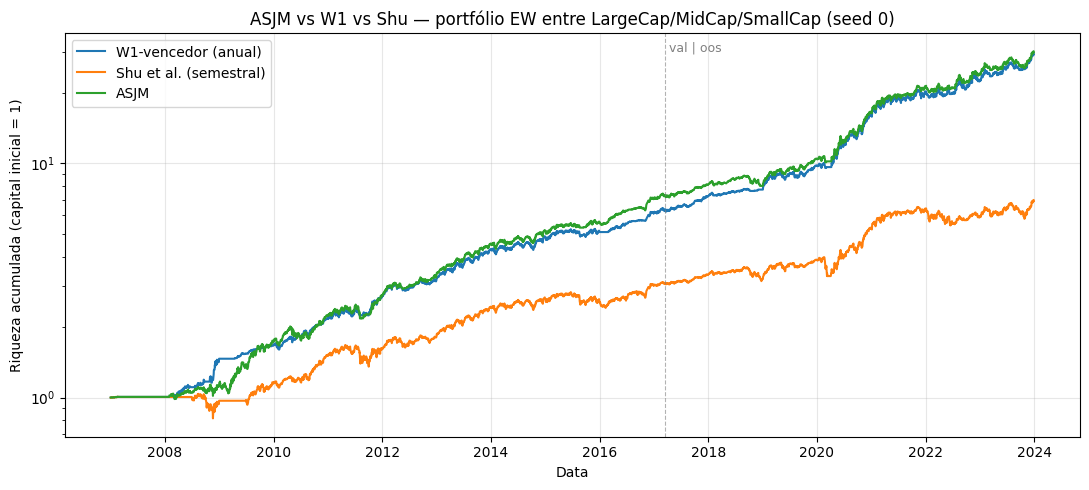

In [13]:
# Recomputa as curvas de wealth acumulado para cada config-asset-seed
def recompute_returns_for_plot(config, asset, seed):
    if config.recal_frequency == 'asjm':
        blocks, _ = generate_asjm_refit_dates(asset, er, asset_data[asset][1],
                                              asset_data[asset][2], config, seed)
    else:
        rm = _rebal_months_from_freq(config.recal_frequency)
        blocks = _generate_refit_dates(er.index, TEST_START, TEST_END, rm, config.train_years)
    # Reusa o motor para extrair retornos
    res = run_with_custom_blocks(
        config=config, asset=asset, er_df=er, rf_s=rf,
        features=asset_data[asset][1], vol_estimators=asset_data[asset][2],
        true_regimes=asset_data[asset][3], blocks=blocks, seed=seed,
    )
    return res

# Para visualização: usa apenas seed=0 e calcula a wealth curve agregada (média entre 3 ativos)
fig, ax = plt.subplots(figsize=(11, 5))
colors = {'w1_winner_annual': '#1f77b4', 'shu2024_semiannual': '#ff7f0e',
          'asjm_cluster_stability': '#2ca02c'}
labels = {'w1_winner_annual': 'W1-vencedor (anual)',
          'shu2024_semiannual': 'Shu et al. (semestral)',
          'asjm_cluster_stability': 'ASJM'}

# Curvas de portfólio igualmente ponderado entre os 3 ativos (seed 0)
for cfg in configs:
    portfolio_rets_per_asset = []
    common_idx = None
    for asset in ASSETS_RUN:
        # Roda novamente para obter a série de retornos diários
        # Reusa a lógica de run_with_custom_blocks expondo a série interna via rerun
        # Para simplicidade, recalcula aqui o caminho
        ohlc, features, vol_est, true_reg = asset_data[asset]
        if cfg.recal_frequency == 'asjm':
            blocks, _ = generate_asjm_refit_dates(asset, er, features, vol_est, cfg, seed=0)
        else:
            rm = _rebal_months_from_freq(cfg.recal_frequency)
            blocks = _generate_refit_dates(er.index, TEST_START, TEST_END, rm, cfg.train_years)
        # Recompõe retornos
        all_rets, all_dates = [], []
        for train_end, ts, te in blocks:
            train_idx = er.index[er.index <= train_end]
            test_idx  = er.index[(er.index >= ts) & (er.index <= te)]
            if len(train_idx) < 252 or len(test_idx) == 0:
                continue
            vol_s = pd.Series(vol_est.get(cfg.vol_estimator, vol_est['close_to_close']),
                              index=er.index).reindex(er.index).ffill()
            feat_enriched = _prepare_clustering_features(features, vol_s, cfg.feature_set)
            X_train = feat_enriched.reindex(train_idx).dropna()
            if len(X_train) < 100:
                continue
            try:
                jm = JumpModel(n_states=cfg.n_regimes, jump_pen=cfg.lambda_penalty, random_state=0)
                jm.fit(X_train.values)
            except Exception:
                continue
            er_train = er[asset].reindex(X_train.index).values
            stats_dict = jm.regime_stats(er_train)
            bull_state = max(stats_dict, key=lambda k: stats_dict[k]['mean_daily'])
            jm_labels = (jm.labels_ != bull_state).astype(int)
            X_test = feat_enriched.reindex(test_idx).ffill().dropna()
            if len(X_test) == 0:
                continue
            pred = _forecast_regime(config=cfg, X_train=X_train, y_train=jm_labels,
                                    X_test=X_test, seed=0)
            er_test = er[asset].reindex(test_idx).fillna(0.0).values
            port_ret = _simple_portfolio(pred_labels=pred, er=er_test,
                                         gamma_trade=cfg.gamma_trade,
                                         gamma_risk=cfg.gamma_risk,
                                         leverage_max=cfg.leverage_max)
            all_rets.append(pd.Series(port_ret, index=test_idx))
        if all_rets:
            portfolio_rets_per_asset.append(pd.concat(all_rets))
    if portfolio_rets_per_asset:
        # EW entre os 3 ativos
        df_ret = pd.concat(portfolio_rets_per_asset, axis=1).fillna(0.0)
        ew_ret = df_ret.mean(axis=1)
        wealth = (1 + ew_ret).cumprod()
        ax.plot(wealth.index, wealth.values, label=labels[cfg.name],
                color=colors[cfg.name], lw=1.5)

# Linha vertical dividindo val e oos (60% / 40%)
test_dates = er.index[(er.index >= TEST_START) & (er.index <= TEST_END)]
split_idx = int(len(test_dates) * W1_VALIDATION_FRACTION)
ax.axvline(test_dates[split_idx], color='gray', linestyle='--', lw=0.8, alpha=0.6)
ax.text(test_dates[split_idx], ax.get_ylim()[1]*0.95, ' val | oos',
        fontsize=9, color='gray')
ax.set_yscale('log')
ax.set_ylabel('Riqueza acumulada (capital inicial = 1)')
ax.set_xlabel('Data')
ax.set_title('ASJM vs W1 vs Shu — portfólio EW entre LargeCap/MidCap/SmallCap (seed 0)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'asjm_wealth_curves.png', dpi=160, bbox_inches='tight')
plt.show()


## 14 · Persistência dos resultados

In [14]:
# Salva resultados em parquet (sem o campo 'events' que é lista de dicts)
res_to_save = results_df.drop(columns=[c for c in ['events'] if c in results_df.columns], errors='ignore')
pl.from_pandas(res_to_save).write_parquet(OUT_PATH)
events_path = RESULTS_DIR / 'asjm_events.csv'
events_df.to_csv(events_path, index=False)
summary_path = RESULTS_DIR / 'asjm_summary.csv'
summary.to_csv(summary_path)

print(f'Resultados:  {OUT_PATH}')
print(f'Eventos:     {events_path}')
print(f'Resumo:      {summary_path}')


Resultados:  /home/researcher/app/results/ablation/asjm_proof_of_concept.parquet
Eventos:     /home/researcher/app/results/ablation/asjm_events.csv
Resumo:      /home/researcher/app/results/ablation/asjm_summary.csv
